# Wine Quality Prediction Analysis

## 1. Problem Statement

Wine producers aim to maintain consistent quality in their products. However, wine quality depends on several physicochemical properties such as acidity, sugar content, alcohol percentage, and pH level.

Since human taste evaluation is subjective, we need a **data-driven approach** to predict wine quality objectively.

The problem is to analyze the physicochemical characteristics of wine samples and build a predictive understanding of how these properties influence wine quality.

---

## 2. Objective

Predict the quality of wine on a scale (0 to 10) based on physicochemical properties such as acidity, pH, alcohol content, and sugar levels.

**Goals:**
- Identify which features most strongly influence wine quality
- Understand how chemical properties relate to taste perception
- Determine whether wine quality can be reliably predicted using measurable attributes

---

## 3. Dataset Summary

The dataset contains multiple physicochemical attributes of wine samples along with a quality score.
- Each **row** represents one wine sample
- Each **column** represents a measured property or the target variable (quality)

---

## 3.1 Feature Descriptions

### 1. Fixed Acidity
- Refers to non-volatile acids that do not evaporate easily (e.g., tartaric acid)
- Contributes to the sour taste of wine
- Higher fixed acidity → sharper taste
- Important for preservation and stability

### 2. Volatile Acidity
- Refers to acids that can evaporate, mainly acetic acid
- High volatile acidity can cause a vinegar-like smell
- Excessive levels reduce wine quality
- Lower values are generally preferred

### 3. Citric Acid
- A weak organic acid found naturally in fruits
- Adds freshness and flavor
- Enhances stability
- Moderate levels improve taste

### 4. Residual Sugar
- The amount of sugar left after fermentation (measured in g/L)
- Higher residual sugar → sweeter wine
- Low residual sugar → dry wine
- Directly affects sweetness and overall flavor profile

### 5. Chlorides
- Amount of salt in wine
- High chloride levels may give a salty taste
- Excess levels can negatively affect quality

### 6. Free Sulfur Dioxide
- The free form of SO₂ available in wine
- Prevents microbial growth
- Acts as an antioxidant
- Protects wine from spoilage

### 7. Total Sulfur Dioxide
- Total amount of bound and free sulfur dioxide
- Helps preserve wine
- Too much may affect taste and smell

### 8. Density
- Mass per unit volume of wine
- Higher sugar → higher density
- Higher alcohol → lower density

### 9. pH
- Measures acidity/alkalinity of wine
- Lower pH → more acidic
- Higher pH → less acidic
- Most wines have pH between 3 and 4
- Affects stability, color, and taste

### 10. Sulphates
- Potassium sulfate content
- Contributes to microbial stability
- Can enhance flavor
- Moderate levels improve wine quality

### 11. Alcohol
- Percentage of alcohol content
- Produced during fermentation
- Higher alcohol often correlates with higher quality
- Strongly influences taste and body

### 12. Quality (Target Variable)
- Score assigned by wine experts
- Ranges from 0 to 10
- Represents overall taste evaluation
- **This is the value we aim to predict**

---

In [33]:
import pandas as pd              
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns

In [34]:
df=pd.read_csv('dataproject.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [35]:
# Display the last 5 rows of the DataFrame
# Useful for checking the end of the dataset and verifying data import
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [36]:
# Display a concise summary of the DataFrame, including column names, data types, and non-null counts
# This helps understand the structure and quality of the dataset
# Useful for identifying missing values and data types before analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [37]:
# Get the total number of rows in the DataFrame
# Useful for understanding dataset size
len(df)

1143

In [38]:
# Get the shape of the DataFrame (rows, columns)
# Helps to quickly see the structure of the dataset
df.shape

(1143, 13)

In [39]:
# Generate descriptive statistics for all columns
# Transpose for easier reading (columns as rows)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [40]:
# Count unique values in each column
# Useful for understanding categorical diversity and feature uniqueness
df.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64

In [41]:
# Count occurrences of each quality value, sorted by index
# Useful for understanding class distribution in the target variable
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

##  3. Data Handling

###  3.1 Dropping non significant columns

In [42]:
# Remove the 'Id' column if it exists
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

Dropping Id column as it is insignificant

### 3.2 Missing Data Checking and Handling

In [43]:
# Check for missing values in each column
# Helps identify columns that need cleaning or imputation
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Seems like there are no null rows, still handling the null cases (just in case, if needed for other datasets)

In [44]:
# Handling missing values
# Remove rows where the target variable 'quality' is missing
df = df.dropna(subset=['quality'])  # target variable
# dropna() deletes rows containing missing values
# subset=['quality'] applies the deletion only if quality is missing, not if other columns have missing values

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
# Selects columns that contain numerical data types (int, float) and stores their column names in num_cols
# df.select_dtypes(include=np.number) selects only numerical columns from the DataFrame df
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# Calculates the median for each numerical column and replaces NaN values in those columns with the respective median

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
# Similar to (include=np.number), (include='object') selects columns with categorical data types (strings/objects)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)
# Computes the mode (most frequent value) of that column and replaces missing (NaN) values with the mode
# The index [0] is used because the mode() function returns a Series; [0] extracts a single most frequent value required for missing value imputation
# infer_objects(copy=False) handles the deprecated downcasting behavior

print(f"Missing values after handling: {df.isnull().sum().sum()}")

Missing values after handling: 0


In [45]:
len(df)

1143

Here, we see that the no. of rows before and after the missing data checking and handling are the same. This confirms that there were no empty rows.

### 3.3 Duplicate Data Checking and Handling

In [46]:
# Count the number of duplicate rows in the DataFrame
duplicates = df.duplicated().sum()
duplicates

np.int64(125)

### i. Dropping Duplicate Rows

In [47]:
# Remove duplicate rows from the DataFrame
df = df.drop_duplicates()

In [48]:
# Check the shape of the DataFrame after removing duplicates
# Ensures data cleaning steps are reflected in the dataset
df.shape

(1018, 12)

<p>We see the no. of data before and after dropping the duplicate data are 1143 and 1018 respecticely suggesting that 125 duplicate datas were removed</p>

## EDA (Explanatory Data Analysis)

In [49]:
# Calculate the mean of each feature grouped by wine quality
# Useful for understanding how features vary across quality levels
df.groupby('quality').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450000,0.897500,0.211667,2.666667,0.105333,8.166667,24.500000,0.997682,3.361667,0.550000,9.691667
4,7.809091,0.700000,0.165758,2.566667,0.094788,14.848485,40.606061,0.996669,3.391212,0.637879,10.260606
5,8.134642,0.587436,0.239307,2.527252,0.091880,16.766744,56.001155,0.997041,3.304088,0.614573,9.912702
6,8.328117,0.504731,0.269633,2.444010,0.085687,15.221271,40.097800,0.996597,3.320929,0.674328,10.669030
7,8.775410,0.390615,0.382049,2.750410,0.074697,14.213115,37.459016,0.995946,3.290164,0.744016,11.541120
8,8.680000,0.414000,0.426000,2.646667,0.070200,11.466667,30.266667,0.995443,3.246667,0.774000,12.000000


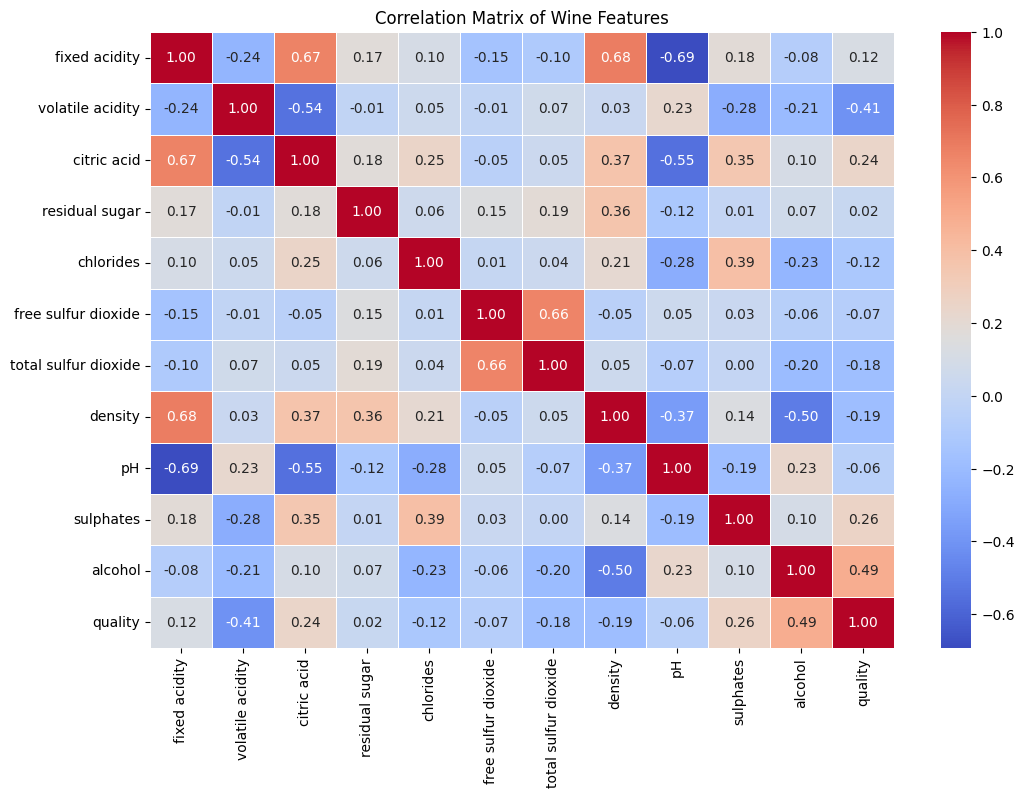

In [50]:
# Plot the correlation matrix of all features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Wine Features')
plt.show()

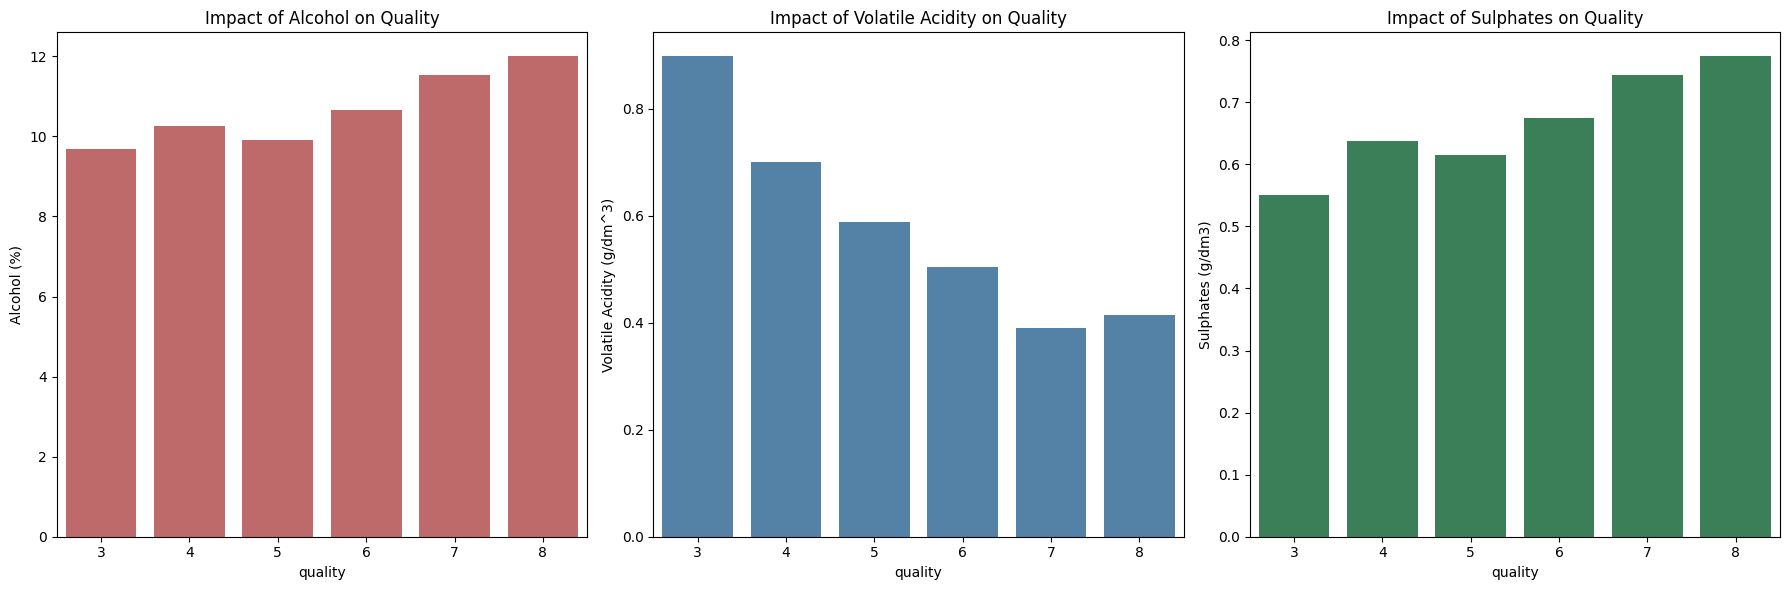

In [51]:
# Visualize the impact of key features on wine quality using bar plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Alcohol vs Quality (Positive Correlation expected)
# We expect higher bars for higher quality
sns.barplot(x='quality', y='alcohol', data=df, ax=axes[0], color='indianred', errorbar=None)
axes[0].set_title('Impact of Alcohol on Quality')
axes[0].set_ylabel('Alcohol (%)')

# 2. Volatile Acidity vs Quality (Negative Correlation expected)
# We expect lower bars for higher quality (since this is "vinegar" taste)
sns.barplot(x='quality', y='volatile acidity', data=df, ax=axes[1], color='steelblue', errorbar=None)
axes[1].set_title('Impact of Volatile Acidity on Quality')
axes[1].set_ylabel('Volatile Acidity (g/dm^3)')

# 3. Sulphates vs Quality (Positive Correlation expected)
# Sulphates act as an antimicrobial and antioxidant
sns.barplot(x='quality', y='sulphates', data=df, ax=axes[2], color='seagreen', errorbar=None)
axes[2].set_title('Impact of Sulphates on Quality')
axes[2].set_ylabel('Sulphates (g/dm3)')

plt.tight_layout()
plt.show()

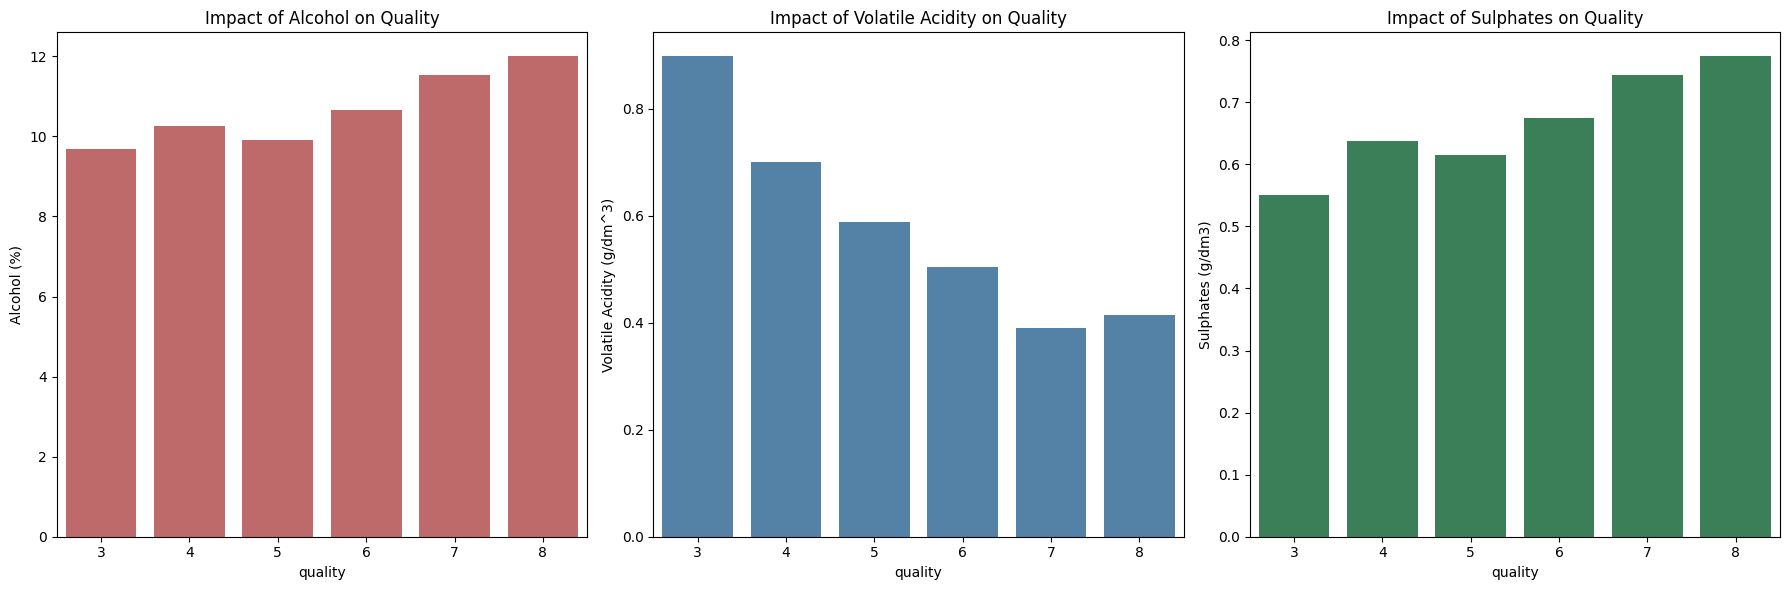

In [52]:
# Visualize the impact of key features on wine quality using bar plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Alcohol vs Quality (Positive Correlation expected)
# We expect higher bars for higher quality
sns.barplot(x='quality', y='alcohol', data=df, ax=axes[0], color='indianred', errorbar=None)
axes[0].set_title('Impact of Alcohol on Quality')
axes[0].set_ylabel('Alcohol (%)')

# 2. Volatile Acidity vs Quality (Negative Correlation expected)
# We expect lower bars for higher quality (since this is "vinegar" taste)
sns.barplot(x='quality', y='volatile acidity', data=df, ax=axes[1], color='steelblue', errorbar=None)
axes[1].set_title('Impact of Volatile Acidity on Quality')
axes[1].set_ylabel('Volatile Acidity (g/dm^3)')

# 3. Sulphates vs Quality (Positive Correlation expected)
# Sulphates act as an antimicrobial and antioxidant
sns.barplot(x='quality', y='sulphates', data=df, ax=axes[2], color='seagreen', errorbar=None)
axes[2].set_title('Impact of Sulphates on Quality')
axes[2].set_ylabel('Sulphates (g/dm3)')

plt.tight_layout()
plt.show()

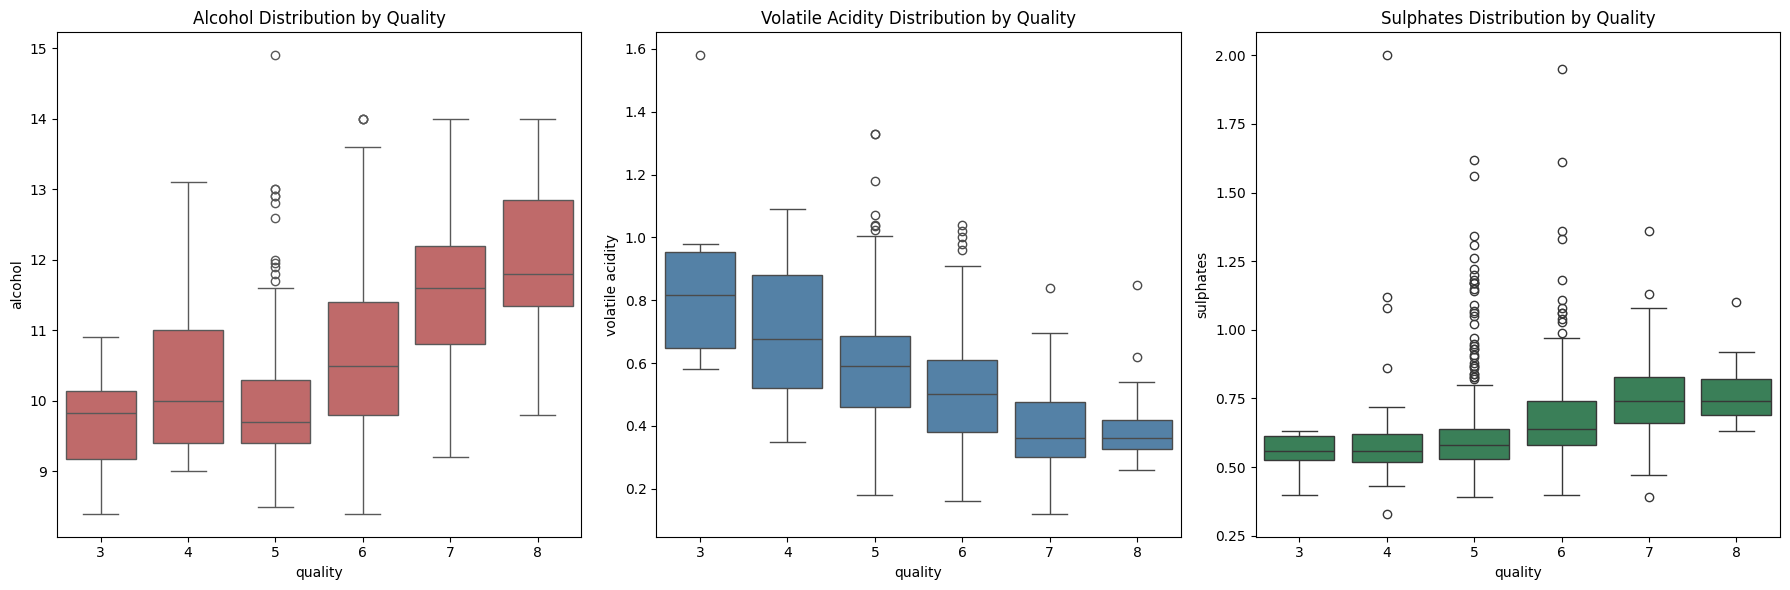

In [53]:
# Visualize the distribution of key features by wine quality using box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Alcohol Distribution
sns.boxplot(x='quality', y='alcohol', data=df, ax=axes[0], color='indianred')
axes[0].set_title('Alcohol Distribution by Quality')

# 2. Volatile Acidity Distribution
sns.boxplot(x='quality', y='volatile acidity', data=df, ax=axes[1], color='steelblue')
axes[1].set_title('Volatile Acidity Distribution by Quality')

# 3. Sulphates Distribution
sns.boxplot(x='quality', y='sulphates', data=df, ax=axes[2], color='seagreen')
axes[2].set_title('Sulphates Distribution by Quality')

plt.tight_layout()
plt.show()

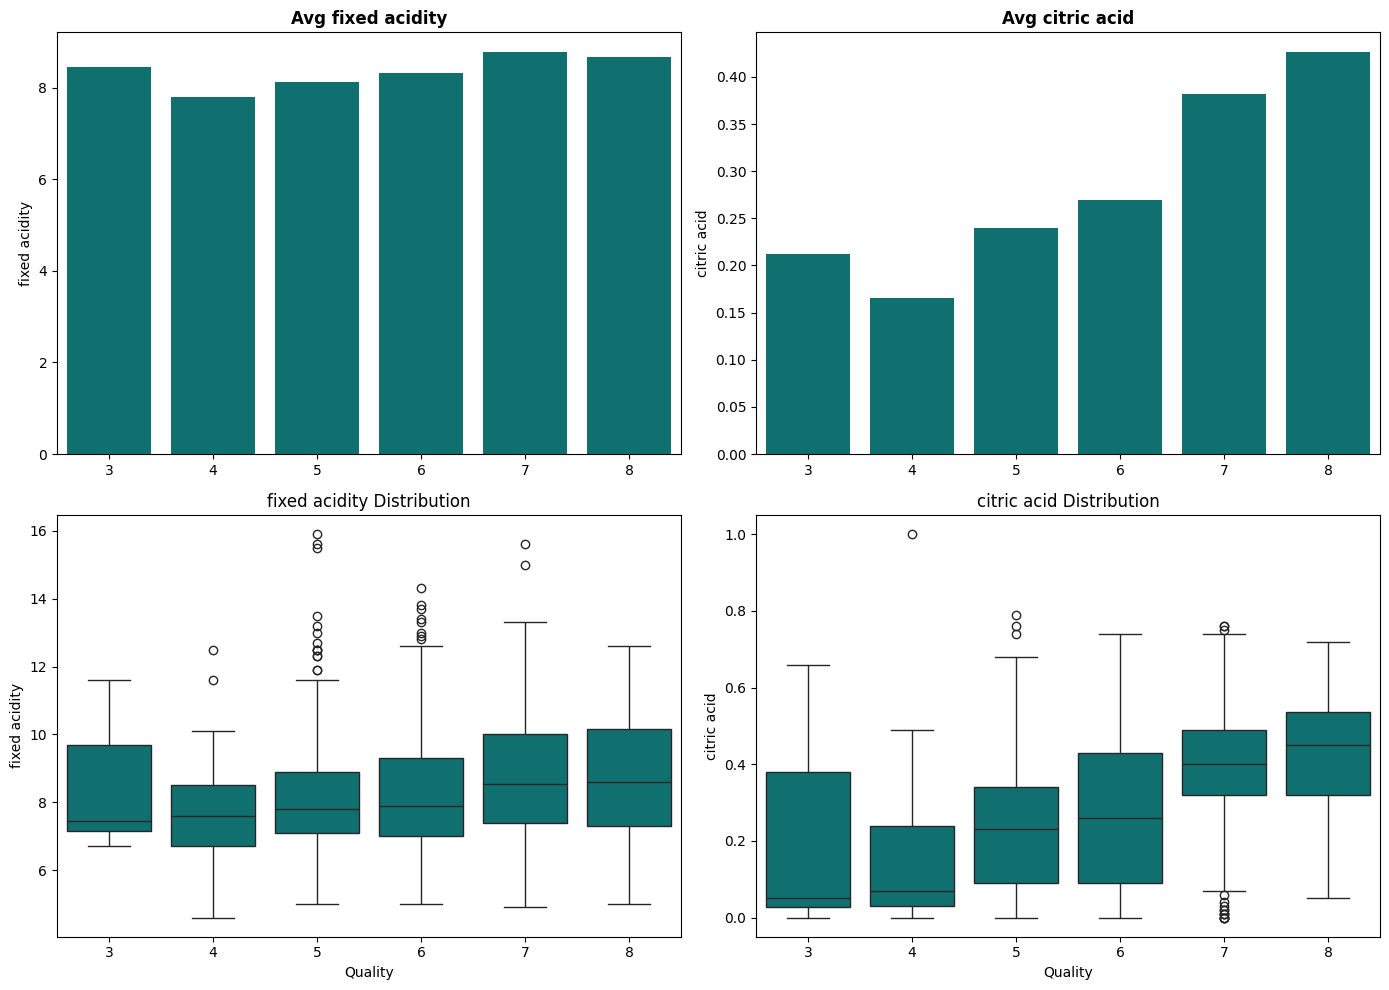

In [54]:
# Analyze the impact and distribution of 'fixed acidity' and 'citric acid' features by wine quality
features_1 = ['fixed acidity', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features_1):
    # Bar plot for average value by quality
    sns.barplot(x='quality', y=col, data=df, ax=axes[0, i], color='teal', errorbar=None)
    axes[0, i].set_title(f'Avg {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    
    # Box plot for distribution by quality
    sns.boxplot(x='quality', y=col, data=df, ax=axes[1, i], color='teal')
    axes[1, i].set_title(f'{col} Distribution', fontsize=12)
    axes[1, i].set_xlabel('Quality')

plt.tight_layout()
plt.show()

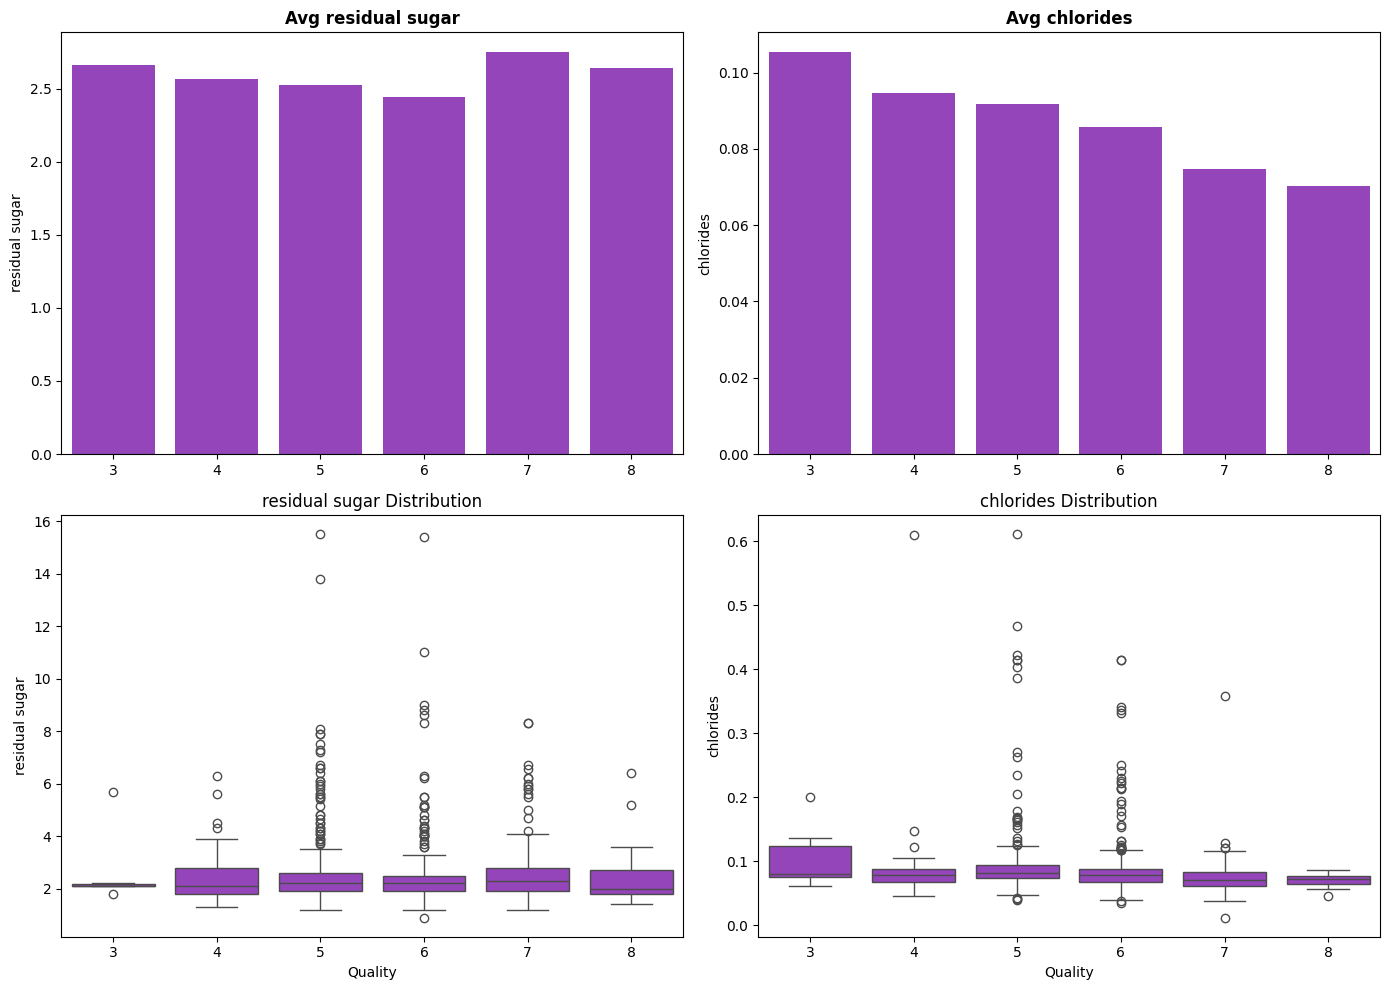

In [55]:
# Analyze the impact and distribution of 'residual sugar' and 'chlorides' features by wine quality
features_2 = ['residual sugar', 'chlorides']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features_2):
    # Bar plot for average value by quality
    sns.barplot(x='quality', y=col, data=df, ax=axes[0, i], color='darkorchid', errorbar=None)
    axes[0, i].set_title(f'Avg {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    
    # Box plot for distribution by quality
    sns.boxplot(x='quality', y=col, data=df, ax=axes[1, i], color='darkorchid')
    axes[1, i].set_title(f'{col} Distribution', fontsize=12)
    axes[1, i].set_xlabel('Quality')

plt.tight_layout()
plt.show()

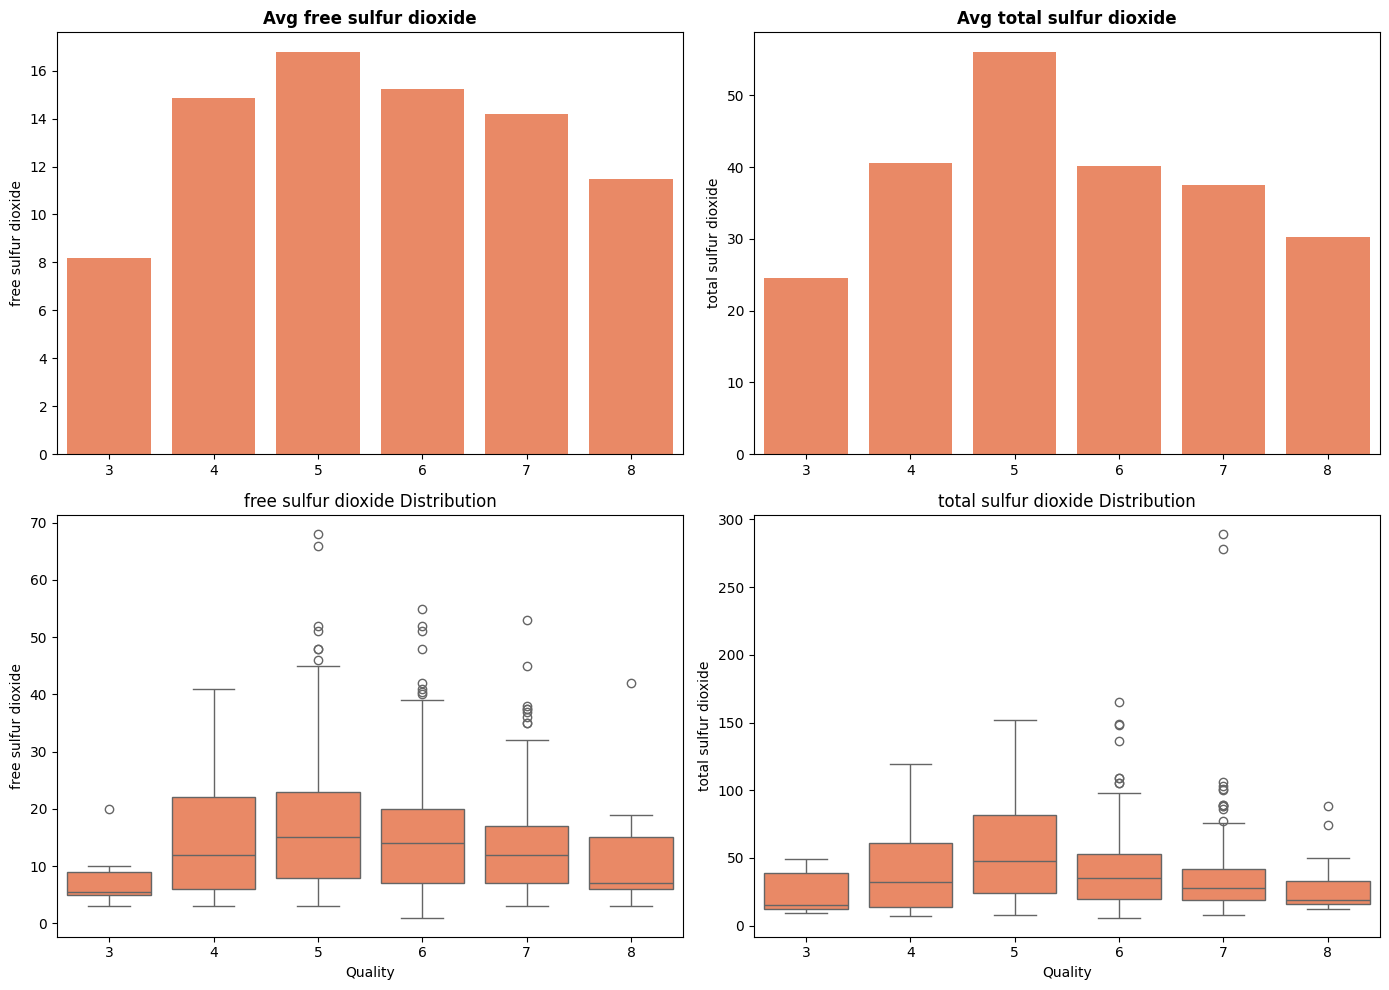

In [56]:
# Analyze the impact and distribution of 'free sulfur dioxide' and 'total sulfur dioxide' features by wine quality
features_3 = ['free sulfur dioxide', 'total sulfur dioxide']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features_3):
    # Bar plot for average value by quality
    sns.barplot(x='quality', y=col, data=df, ax=axes[0, i], color='coral', errorbar=None)
    axes[0, i].set_title(f'Avg {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    
    # Box plot for distribution by quality
    sns.boxplot(x='quality', y=col, data=df, ax=axes[1, i], color='coral')
    axes[1, i].set_title(f'{col} Distribution', fontsize=12)
    axes[1, i].set_xlabel('Quality')

plt.tight_layout()
plt.show()

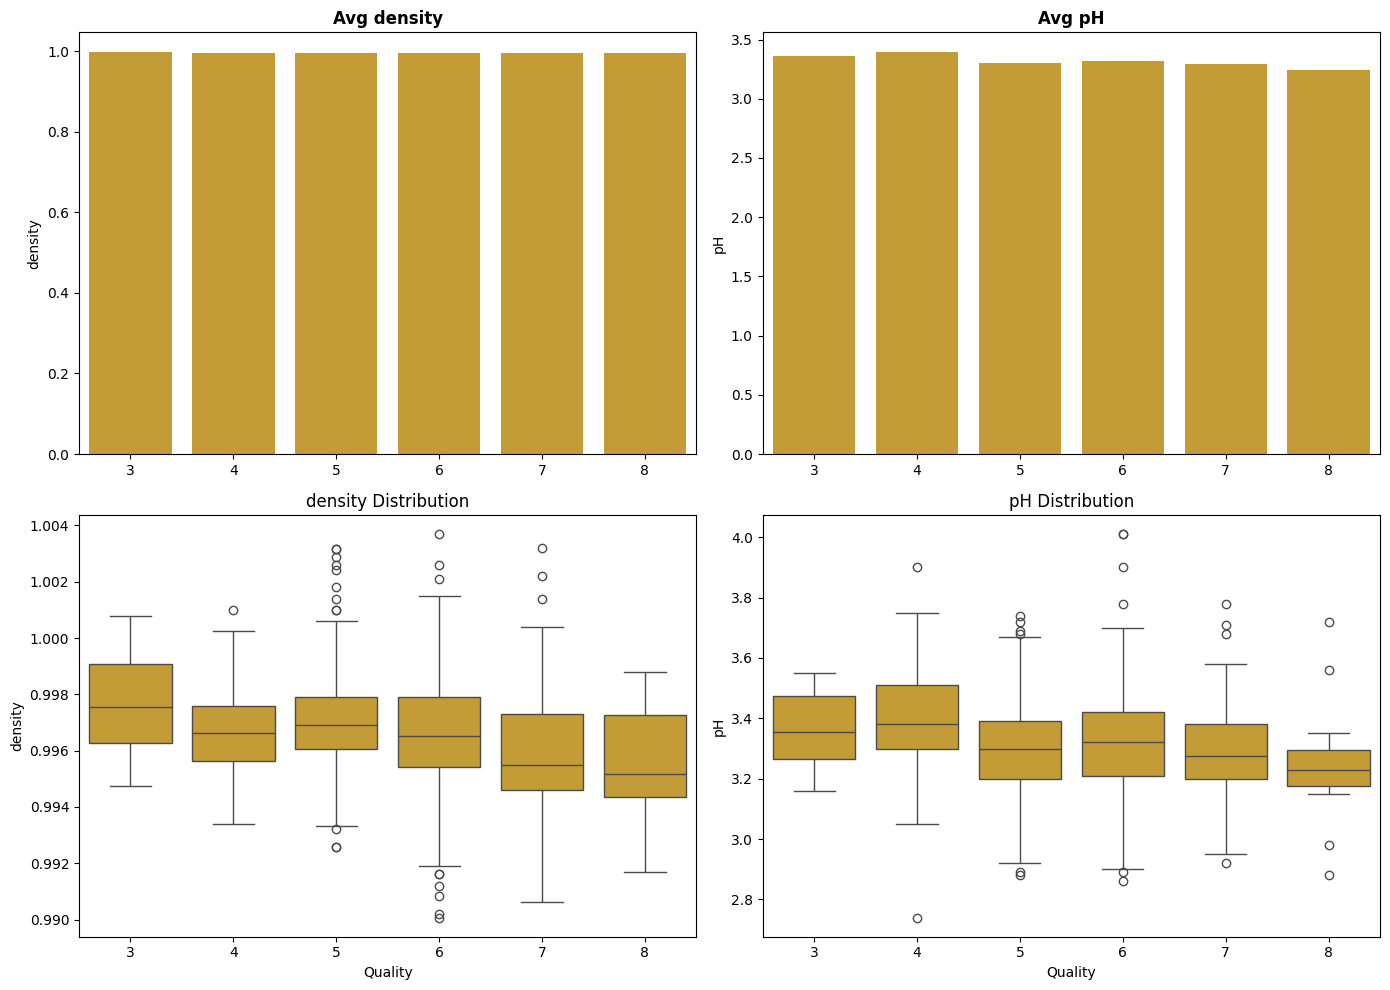

In [57]:
# Analyze the impact and distribution of 'density' and 'pH' features by wine quality
features_4 = ['density', 'pH']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features_4):
    # Bar plot for average value by quality
    sns.barplot(x='quality', y=col, data=df, ax=axes[0, i], color='goldenrod', errorbar=None)
    axes[0, i].set_title(f'Avg {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    
    # Box plot for distribution by quality
    sns.boxplot(x='quality', y=col, data=df, ax=axes[1, i], color='goldenrod')
    axes[1, i].set_title(f'{col} Distribution', fontsize=12)
    axes[1, i].set_xlabel('Quality')

plt.tight_layout()
plt.show()

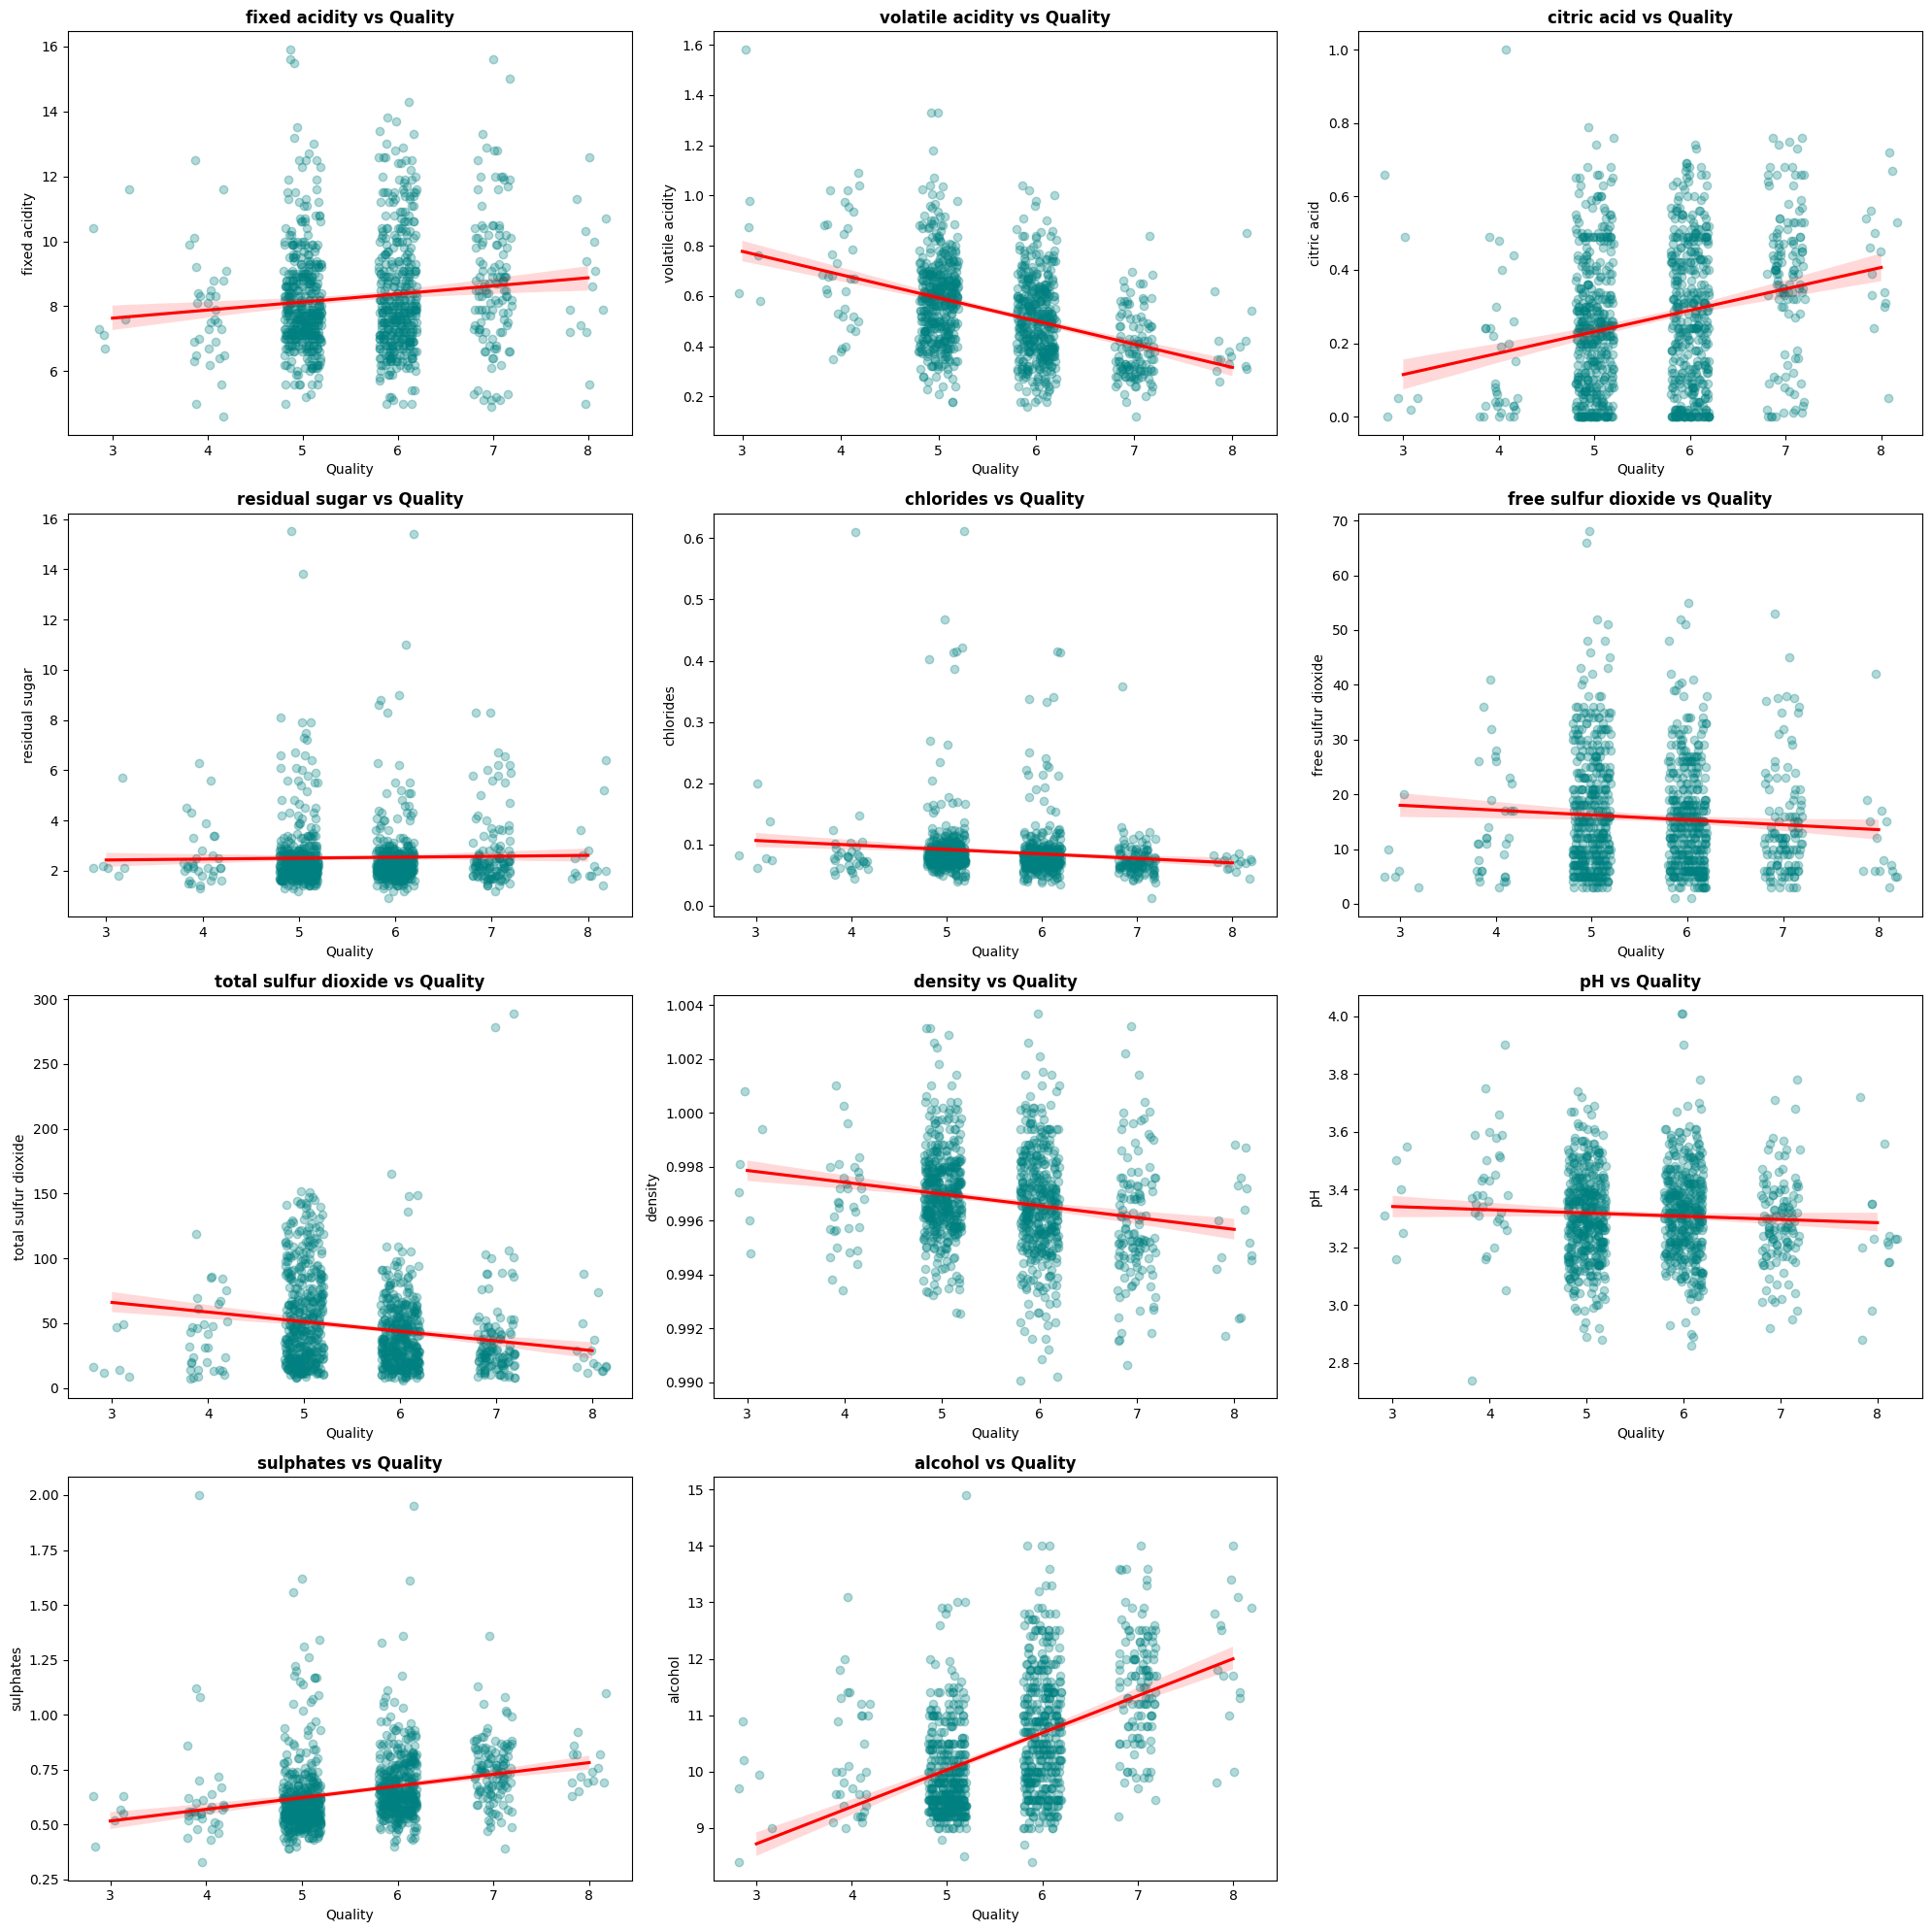

In [58]:
features_all = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(features_all):
    sns.regplot(x='quality', y=col, data=df, ax=axes[i], x_jitter=0.2, 
                line_kws={'color':'red'}, scatter_kws={'alpha':0.3, 'color':'teal'})
    axes[i].set_title(f'{col} vs Quality', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(col)

fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

## Outlier Detection and Handling

Outliers are data points that differ significantly from other observations. They can arise due to variability in measurement, data entry errors, or genuine anomalies. Detecting and handling outliers is crucial in Exploratory Data Analysis (EDA) because outliers can skew statistical analyses and affect model performance.

### Common Methods for Outlier Detection
- **Boxplot (IQR method):** Identifies outliers based on the interquartile range.
- **Z-score:** Flags values that are a certain number of standard deviations from the mean.

### Outlier Handling Strategies
- **Remove outliers:** Drop extreme values from the dataset.
- **Cap values:** Replace outliers with threshold values (winsorization).
- **Impute values:** Replace outliers with mean, median, or mode.

---

#### Example: Detecting and Handling Outliers in Numerical Features


In [59]:
# Detect and handle outliers using the IQR method
# This example applies to all numerical columns

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected")
    # Remove outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# After handling outliers, check shape
print(f"Data shape after outlier removal: {df.shape}")

fixed acidity: 37 outliers detected
volatile acidity: 14 outliers detected
citric acid: 1 outliers detected
residual sugar: 84 outliers detected
chlorides: 60 outliers detected
free sulfur dioxide: 15 outliers detected
total sulfur dioxide: 33 outliers detected
density: 16 outliers detected
pH: 13 outliers detected
sulphates: 22 outliers detected
alcohol: 3 outliers detected
quality: 10 outliers detected
Data shape after outlier removal: (710, 12)


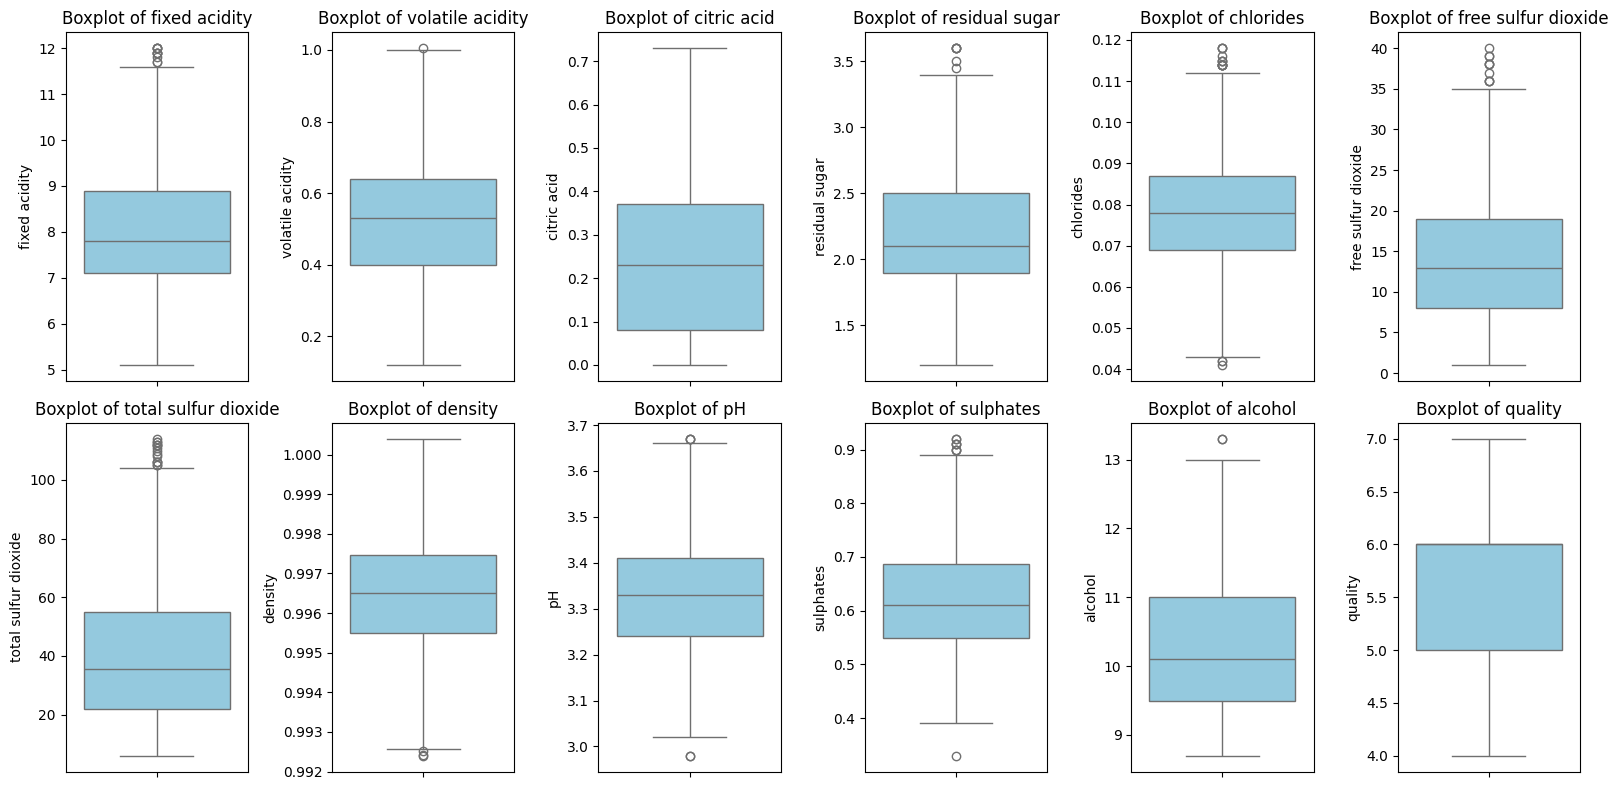

In [60]:
# Visualize box plots for numerical features after outlier removal
# This helps confirm that extreme values have been removed
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, (len(num_cols)+1)//2, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Scaling

In [61]:
# Scale all numeric columns to [0, 1] using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

num_cols = df.select_dtypes(include='number').columns
# Fill missing values with column mean before scaling
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Numeric columns scaled to [0, 1].")
df.head()

Numeric columns scaled to [0, 1].


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.333333,0.655367,0.000000,0.291667,0.454545,0.256410,0.259259,0.675,0.768116,0.389831,0.152174,0.333333
1,0.391304,0.858757,0.000000,0.583333,0.740260,0.615385,0.564815,0.550,0.318841,0.593220,0.239130,0.333333
2,0.391304,0.723164,0.054795,0.458333,0.662338,0.358974,0.444444,0.575,0.405797,0.542373,0.239130,0.333333
3,0.884058,0.180791,0.767123,0.291667,0.441558,0.410256,0.500000,0.700,0.260870,0.423729,0.239130,0.666667
5,0.333333,0.610169,0.000000,0.250000,0.441558,0.307692,0.314815,0.675,0.768116,0.389831,0.152174,0.333333


## Feature Distribution

## Skewness Analysis & Log Transformation

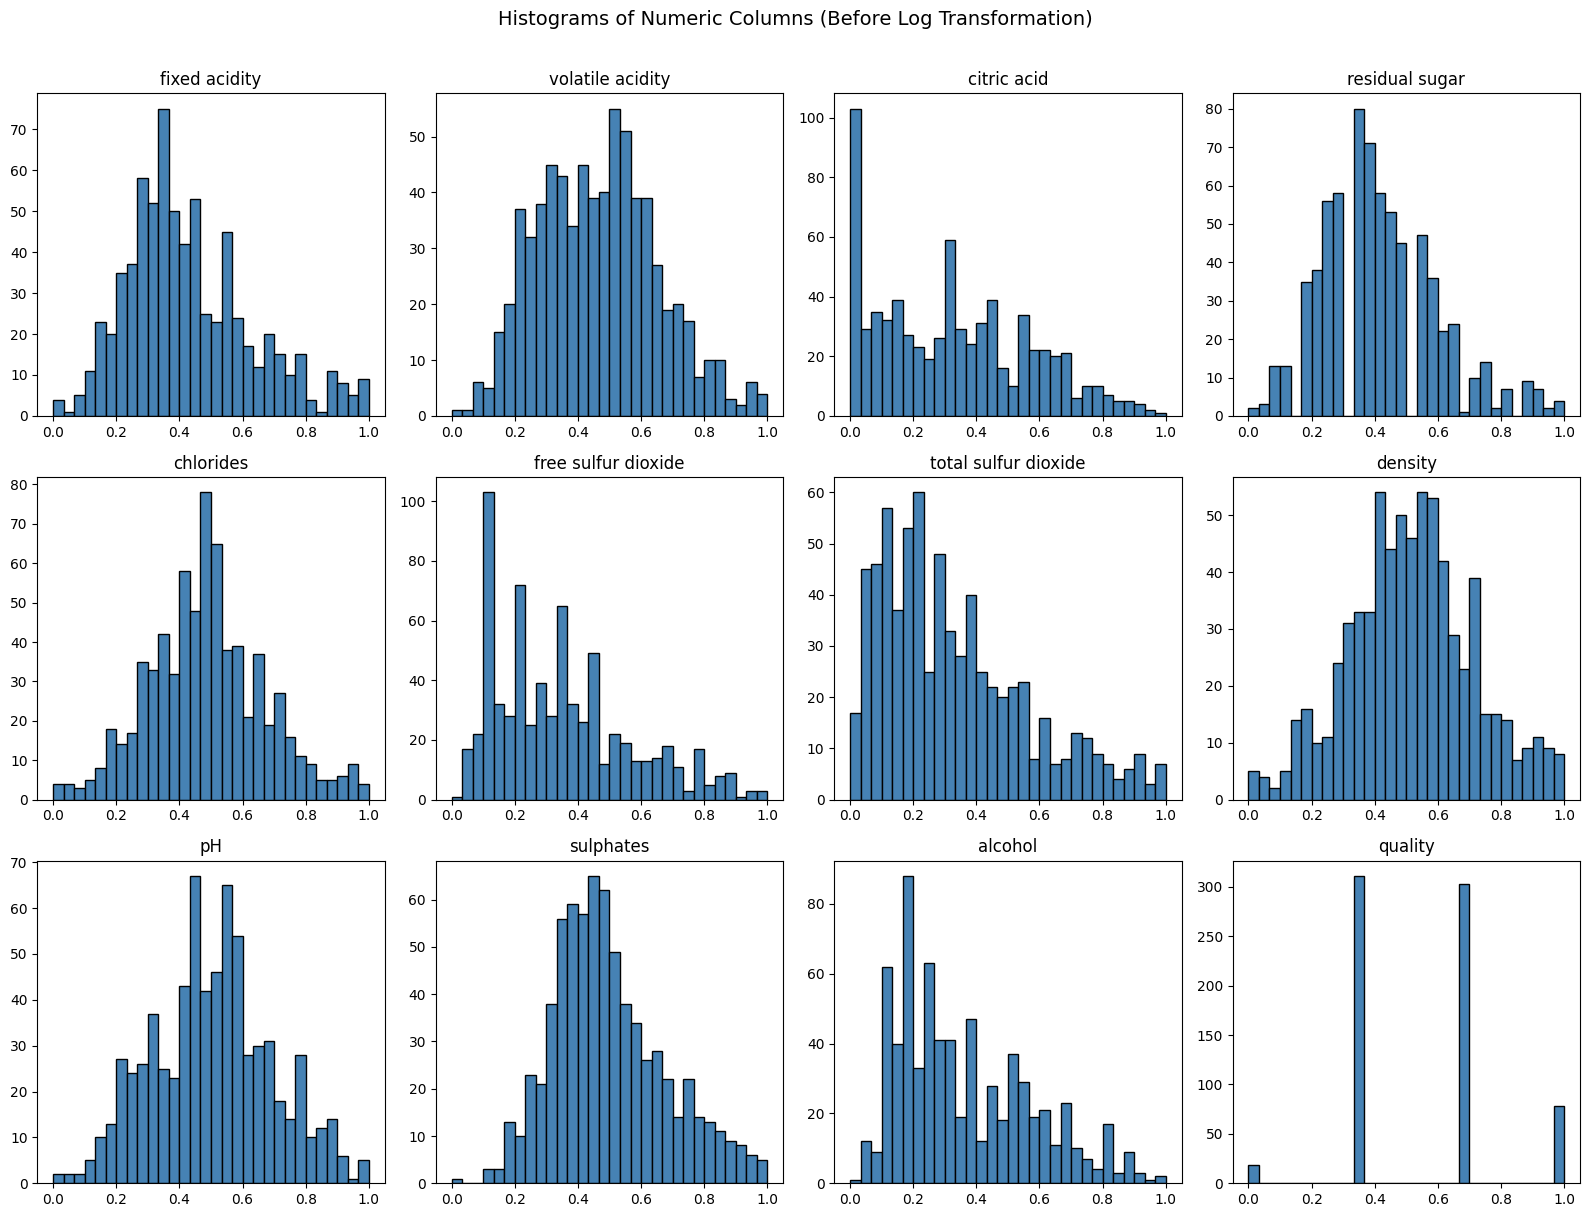

In [62]:
# Histograms for all numeric columns (before transformation)
num_cols = df.select_dtypes(include='number').columns
n = len(num_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of Numeric Columns (Before Log Transformation)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# Check skewness for all numeric columns
skewness = df[num_cols].skew().sort_values(ascending=False)
print("Skewness of Numeric Columns:\n")
for col_name, skew_val in skewness.items():
    label = "High" if abs(skew_val) > 1 else "Moderate" if abs(skew_val) > 0.5 else "Low"
    print(f"  {col_name:30s} => Skewness: {skew_val:+.4f}  ({label})")

# Identify skewed columns (|skewness| > 0.5)
skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()
print(f"\nColumns with notable skewness (|skew| > 0.5): {skewed_cols}")

Skewness of Numeric Columns:

  total sulfur dioxide           => Skewness: +0.9010  (Moderate)
  free sulfur dioxide            => Skewness: +0.7936  (Moderate)
  alcohol                        => Skewness: +0.7643  (Moderate)
  fixed acidity                  => Skewness: +0.7457  (Moderate)
  residual sugar                 => Skewness: +0.6389  (Moderate)
  sulphates                      => Skewness: +0.5526  (Moderate)
  citric acid                    => Skewness: +0.4071  (Low)
  quality                        => Skewness: +0.2737  (Low)
  volatile acidity               => Skewness: +0.2592  (Low)
  chlorides                      => Skewness: +0.2258  (Low)
  pH                             => Skewness: +0.1055  (Low)
  density                        => Skewness: +0.0522  (Low)

Columns with notable skewness (|skew| > 0.5): ['total sulfur dioxide', 'free sulfur dioxide', 'alcohol', 'fixed acidity', 'residual sugar', 'sulphates']


In [64]:
# Apply log1p transformation to skewed columns to correct skewness
# log1p = log(1 + x), safe for zero values
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Verify skewness after transformation
skewness_after = df[skewed_cols].skew().sort_values(ascending=False)
print("Skewness After Log Transformation:\n")
for col_name, skew_val in skewness_after.items():
    label = "High" if abs(skew_val) > 1 else "Moderate" if abs(skew_val) > 0.5 else "Low"
    print(f"  {col_name:30s} => Skewness: {skew_val:+.4f}  ({label})")

Skewness After Log Transformation:

  total sulfur dioxide           => Skewness: +0.5948  (Moderate)
  alcohol                        => Skewness: +0.5254  (Moderate)
  free sulfur dioxide            => Skewness: +0.5097  (Moderate)
  fixed acidity                  => Skewness: +0.4051  (Low)
  residual sugar                 => Skewness: +0.2775  (Low)
  sulphates                      => Skewness: +0.2486  (Low)


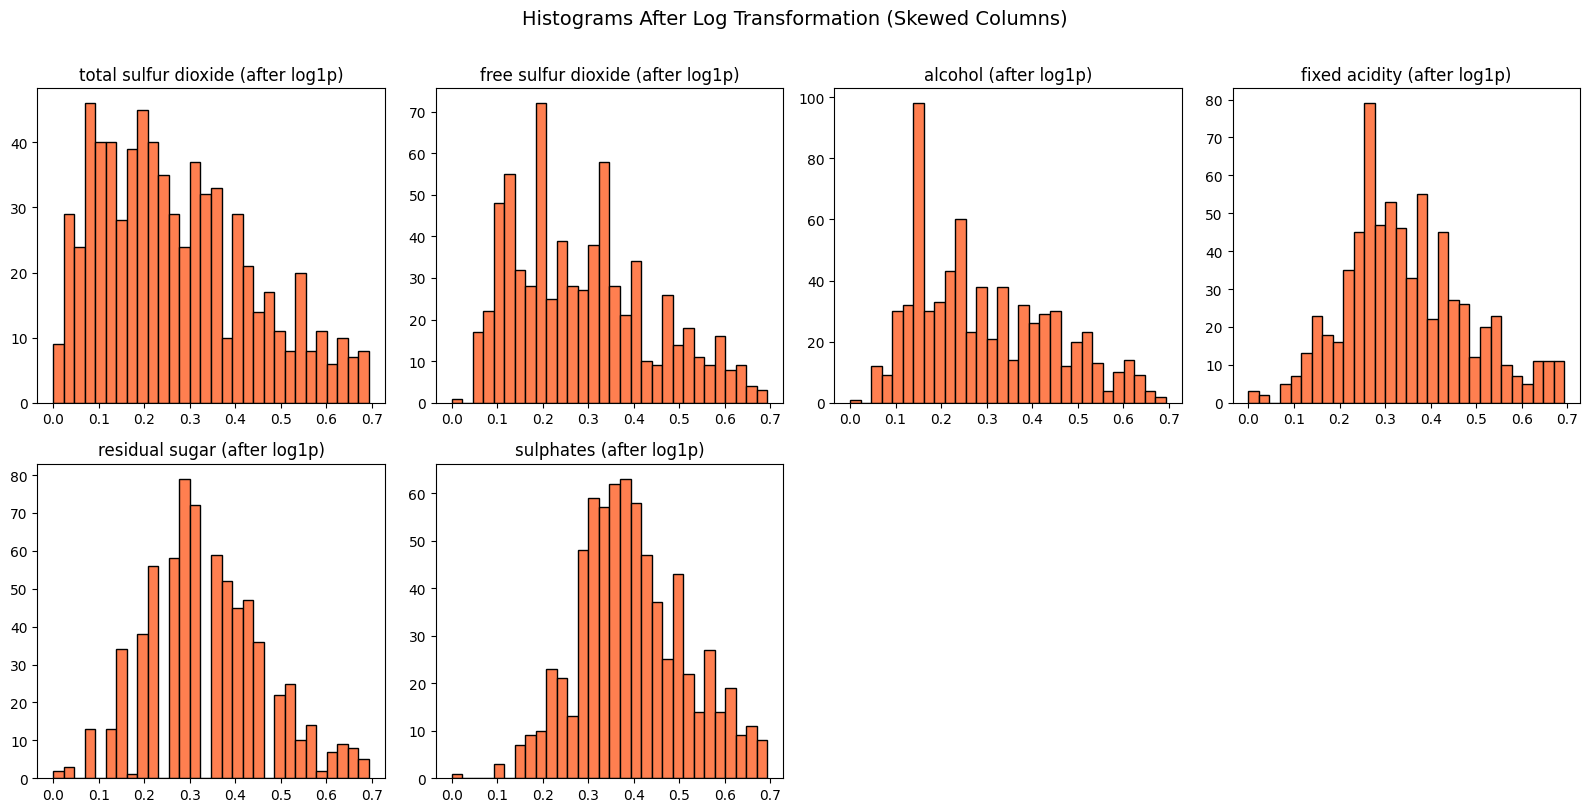

In [65]:
# Histograms after log transformation for skewed columns
n = len(skewed_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    axes[i].hist(df[col], bins=30, color='coral', edgecolor='black')
    axes[i].set_title(f'{col} (after log1p)')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms After Log Transformation (Skewed Columns)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()